# CMSC 25040 Final Project: CycleGAN Image Translation

### Authors: Aeliya Grover | Robert Xing



In [51]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [52]:
# %cd /content/drive/MyDrive/Computer Vision/final_proj_CycleGAN

In [53]:
import torch
import torch.nn as nn
import itertools
import os
import random
import math

from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [54]:
using_gpu = torch.cuda.is_available()

def load_data(data_path: str, batch_size: int = 4) -> DataLoader:
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to tanh output [-1, 1]
    ])

    dataset = datasets.ImageFolder(
        root=data_path,
        transform=transform
    )

    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=using_gpu,
    )

    return data_loader, dataset

In [55]:
if using_gpu:
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [56]:
train_loader, train_set = load_data('./data/train')
test_loader, test_set = load_data('./data/test')

In [57]:
def output_mapping(int_label: int) -> str:
    mapping = {
        0: 'baseball',
        1: 'tennis_ball'
    }
    return mapping[int_label]

def show_img(is_train: bool, idx: int):
    if is_train:
        image, label = train_set[idx]
    else:
        image, label = test_set[idx]

    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5  # denormalize from [-1, 1] to [0, 1]
    img = img.clip(0, 1)
    print(output_mapping(label))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

baseball


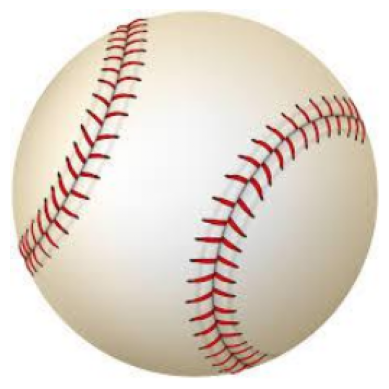

In [58]:
show_img(is_train=True, idx=0)

tennis_ball


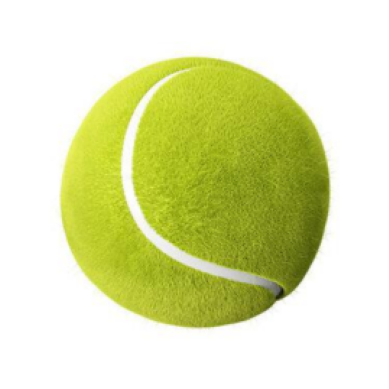

In [59]:
show_img(is_train=True, idx=400)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, num_residual_blocks=4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 7, padding=3),
            nn.InstanceNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        )

        res_blocks = []
        for _ in range(num_residual_blocks):
            res_blocks.append(ResidualBlock(64))
        self.residual = nn.Sequential(*res_blocks)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 7, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.residual(x)
        x = self.decoder(x)
        return x


# essentially PatchGAN
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, padding=1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
"""
Initializing hyperparameters
"""
cyc_lambda = 15
identity_lambda = 5
lr = 0.0002
num_epochs = 150
beta1, beta2 = 0.5, 0.999

"""
Initializing networks + adam optimizers
"""

# G: X->Y (baseball->tennis), F: Y->X (tennis->baseball)
G = Generator(num_residual_blocks=6).to(device)
F = Generator(num_residual_blocks=6).to(device)

D_y = Discriminator().to(device)
D_x = Discriminator().to(device)

criterion_gan = nn.MSELoss()
criterion_cyc = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G_F = torch.optim.Adam(itertools.chain(G.parameters(), F.parameters()),
                               lr=lr, betas=(beta1, beta2))
optimizer_D_X = torch.optim.Adam(D_x.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D_Y = torch.optim.Adam(D_y.parameters(), lr=lr, betas=(beta1, beta2))

def lambda_rule(epoch):
    # linearly decay lr after half of training
    lr_l = 1.0 - max(0, epoch - num_epochs // 2) / (num_epochs // 2)
    return lr_l

scheduler_G_F = torch.optim.lr_scheduler.LambdaLR(optimizer_G_F, lr_lambda=lambda_rule)
scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_rule)
scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_rule)

In [62]:
"""
Load checkpoints if they exist to continue training

If restarting training from the same session, try to restart
from this cell to avoid loss spike from loss of momentum in optimizer
"""

checkpoint_path = 'CycleGAN_tennis_to_baseball.pth'

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    G.load_state_dict(checkpoint['G_state_dict'])
    F.load_state_dict(checkpoint['F_state_dict'])
    D_x.load_state_dict(checkpoint['D_x_state_dict'])
    D_y.load_state_dict(checkpoint['D_y_state_dict'])

    # optimizer states might not exist in older checkpoints
    if 'optimizer_G_F_state_dict' in checkpoint:
        optimizer_G_F.load_state_dict(checkpoint['optimizer_G_F_state_dict'])
        optimizer_D_X.load_state_dict(checkpoint['optimizer_D_X_state_dict'])
        optimizer_D_Y.load_state_dict(checkpoint['optimizer_D_Y_state_dict'])

    if 'scheduler_G_F_state_dict' in checkpoint:
        scheduler_G_F.load_state_dict(checkpoint['scheduler_G_F_state_dict'])
        scheduler_D_X.load_state_dict(checkpoint['scheduler_D_X_state_dict'])
        scheduler_D_Y.load_state_dict(checkpoint['scheduler_D_Y_state_dict'])

    start_epoch = checkpoint.get('epoch', 0) + 1
    g_losses = checkpoint.get('g_losses', [])
    d_losses = checkpoint.get('d_losses', [])

    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch...")
    start_epoch = 0
    g_losses = []
    d_losses = []

Loading checkpoint...
Resumed from epoch 150


In [63]:
"""
Train network for a given number of epochs
The loss after every epoch is printed
"""

for epoch in range(start_epoch, num_epochs):
    G.train()
    F.train()
    D_y.train()
    D_x.train()

    epoch_g_loss = 0
    epoch_d_loss = 0
    num_batches = 0

    for batch_idx, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        images, labels = batch_data
        images = images.to(device)

        # 0: baseball, 1: tennis ball
        mask_x = labels == 0
        mask_y = labels == 1

        real_x = images[mask_x]
        real_y = images[mask_y]

        # take min batch size to handle uneven splits
        min_size = min(real_x.size(0), real_y.size(0))
        real_x = real_x[:min_size]
        real_y = real_y[:min_size]

        optimizer_G_F.zero_grad()

        # G should be identity if real_y is fed: ||G(Y) - Y||
        identity_y = G(real_y)
        loss_identity_y = criterion_identity(identity_y, real_y) * identity_lambda

        identity_x = F(real_x)
        loss_identity_x = criterion_identity(identity_x, real_x) * identity_lambda

        fake_y = G(real_x)
        pred_fake_y = D_y(fake_y)
        loss_G_adv = criterion_gan(pred_fake_y, torch.ones_like(pred_fake_y))

        fake_x = F(real_y)
        pred_fake_x = D_x(fake_x)
        loss_F_adv = criterion_gan(pred_fake_x, torch.ones_like(pred_fake_x))

        # forward cycle: X -> G(X) -> F(G(X)) ≈ X
        cycled_x = F(fake_y)
        loss_cycle_x = criterion_cyc(cycled_x, real_x) * cyc_lambda

        # backward cycle: Y -> F(Y) -> G(F(Y)) ≈ Y
        cycled_y = G(fake_x)
        loss_cycle_y = criterion_cyc(cycled_y, real_y) * cyc_lambda

        loss_G_total = (loss_G_adv + loss_F_adv +
                       loss_cycle_x + loss_cycle_y +
                       loss_identity_x + loss_identity_y)

        loss_G_total.backward()
        optimizer_G_F.step()

        # train D_Y
        optimizer_D_Y.zero_grad()

        pred_real_y = D_y(real_y)
        loss_dy_real = criterion_gan(pred_real_y, torch.ones_like(pred_real_y))

        pred_fake_y = D_y(fake_y.detach())
        loss_dy_fake = criterion_gan(pred_fake_y, torch.zeros_like(pred_fake_y))

        loss_DY = 0.5 * (loss_dy_real + loss_dy_fake)
        loss_DY.backward()
        optimizer_D_Y.step()

        # train D_X
        optimizer_D_X.zero_grad()

        pred_real_x = D_x(real_x)
        loss_dx_real = criterion_gan(pred_real_x, torch.ones_like(pred_real_x))

        pred_fake_x = D_x(fake_x.detach())
        loss_dx_fake = criterion_gan(pred_fake_x, torch.zeros_like(pred_fake_x))

        loss_DX = 0.5 * (loss_dx_real + loss_dx_fake)
        loss_DX.backward()
        optimizer_D_X.step()

        epoch_g_loss += loss_G_total.item()
        epoch_d_loss += (loss_DX.item() + loss_DY.item())
        num_batches += 1

    scheduler_G_F.step()
    scheduler_D_X.step()
    scheduler_D_Y.step()

    if num_batches > 0:
        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}] - G Loss: {avg_g_loss:.4f}, D Loss: {avg_d_loss:.4f}")
        print(f"  LR: {scheduler_G_F.get_last_lr()[0]:.6f}")

    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'G_state_dict': G.state_dict(),
            'F_state_dict': F.state_dict(),
            'D_x_state_dict': D_x.state_dict(),
            'D_y_state_dict': D_y.state_dict(),
            'optimizer_G_F_state_dict': optimizer_G_F.state_dict(),
            'optimizer_D_X_state_dict': optimizer_D_X.state_dict(),
            'optimizer_D_Y_state_dict': optimizer_D_Y.state_dict(),
            'scheduler_G_F_state_dict': scheduler_G_F.state_dict(),
            'scheduler_D_X_state_dict': scheduler_D_X.state_dict(),
            'scheduler_D_Y_state_dict': scheduler_D_Y.state_dict(),
            'g_losses': g_losses,
            'd_losses': d_losses,
        }, checkpoint_path)

        print(f"Checkpoint saved at epoch {epoch+1}")

        G.eval()
        F.eval()
        with torch.no_grad():
            test_batch = next(iter(test_loader))
            test_images, test_labels = test_batch
            test_images = test_images.to(device)

            mask_x_test = test_labels == 0
            mask_y_test = test_labels == 1

            if mask_x_test.any():
                sample_x = test_images[mask_x_test][:1]
                fake_y_sample = G(sample_x)

                fig, axes = plt.subplots(1, 2, figsize=(10, 5))

                # original baseball
                img_x = sample_x[0].cpu().permute(1, 2, 0).numpy()
                img_x = (img_x * 0.5) + 0.5
                axes[0].imshow(img_x.clip(0, 1))
                axes[0].set_title('Original Baseball')
                axes[0].axis('off')

                # translated to tennis ball
                img_y = fake_y_sample[0].cpu().permute(1, 2, 0).numpy()
                img_y = (img_y * 0.5) + 0.5
                axes[1].imshow(img_y.clip(0, 1))
                axes[1].set_title('Generated Tennis Ball')
                axes[1].axis('off')
                plt.suptitle(f'Epoch {epoch+1} - Baseball to Tennis Ball')
                plt.tight_layout()
                plt.show()

            if mask_y_test.any():
                sample_y = test_images[mask_y_test][:1]
                fake_x_sample = F(sample_y)

                fig, axes = plt.subplots(1, 2, figsize=(10, 5))

                # original tennis ball
                img_y = sample_y[0].cpu().permute(1, 2, 0).numpy()
                img_y = (img_y * 0.5) + 0.5
                axes[0].imshow(img_y.clip(0, 1))
                axes[0].set_title('Original Tennis Ball')
                axes[0].axis('off')

                # translated to baseball
                img_x = fake_x_sample[0].cpu().permute(1, 2, 0).numpy()
                img_x = (img_x * 0.5) + 0.5
                axes[1].imshow(img_x.clip(0, 1))
                axes[1].set_title('Generated Baseball')
                axes[1].axis('off')
                plt.suptitle(f'Epoch {epoch+1} - Tennis Ball to Baseball')
                plt.tight_layout()
                plt.show()

print("\nTraining complete!")


Training complete!


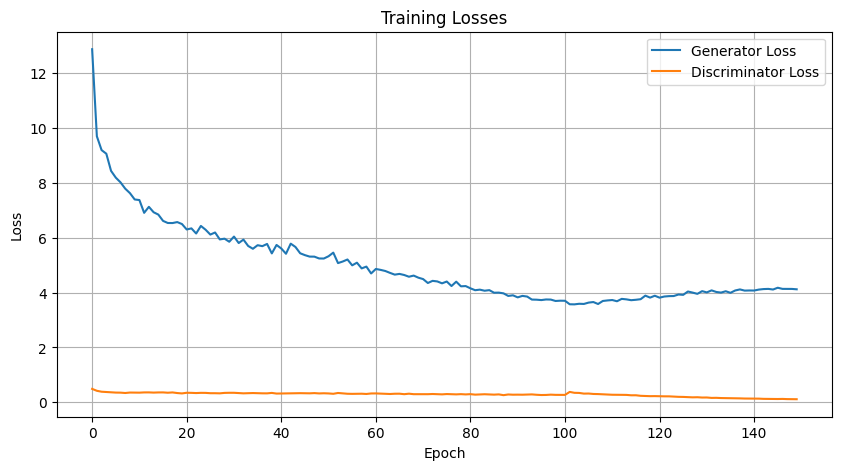

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.show()

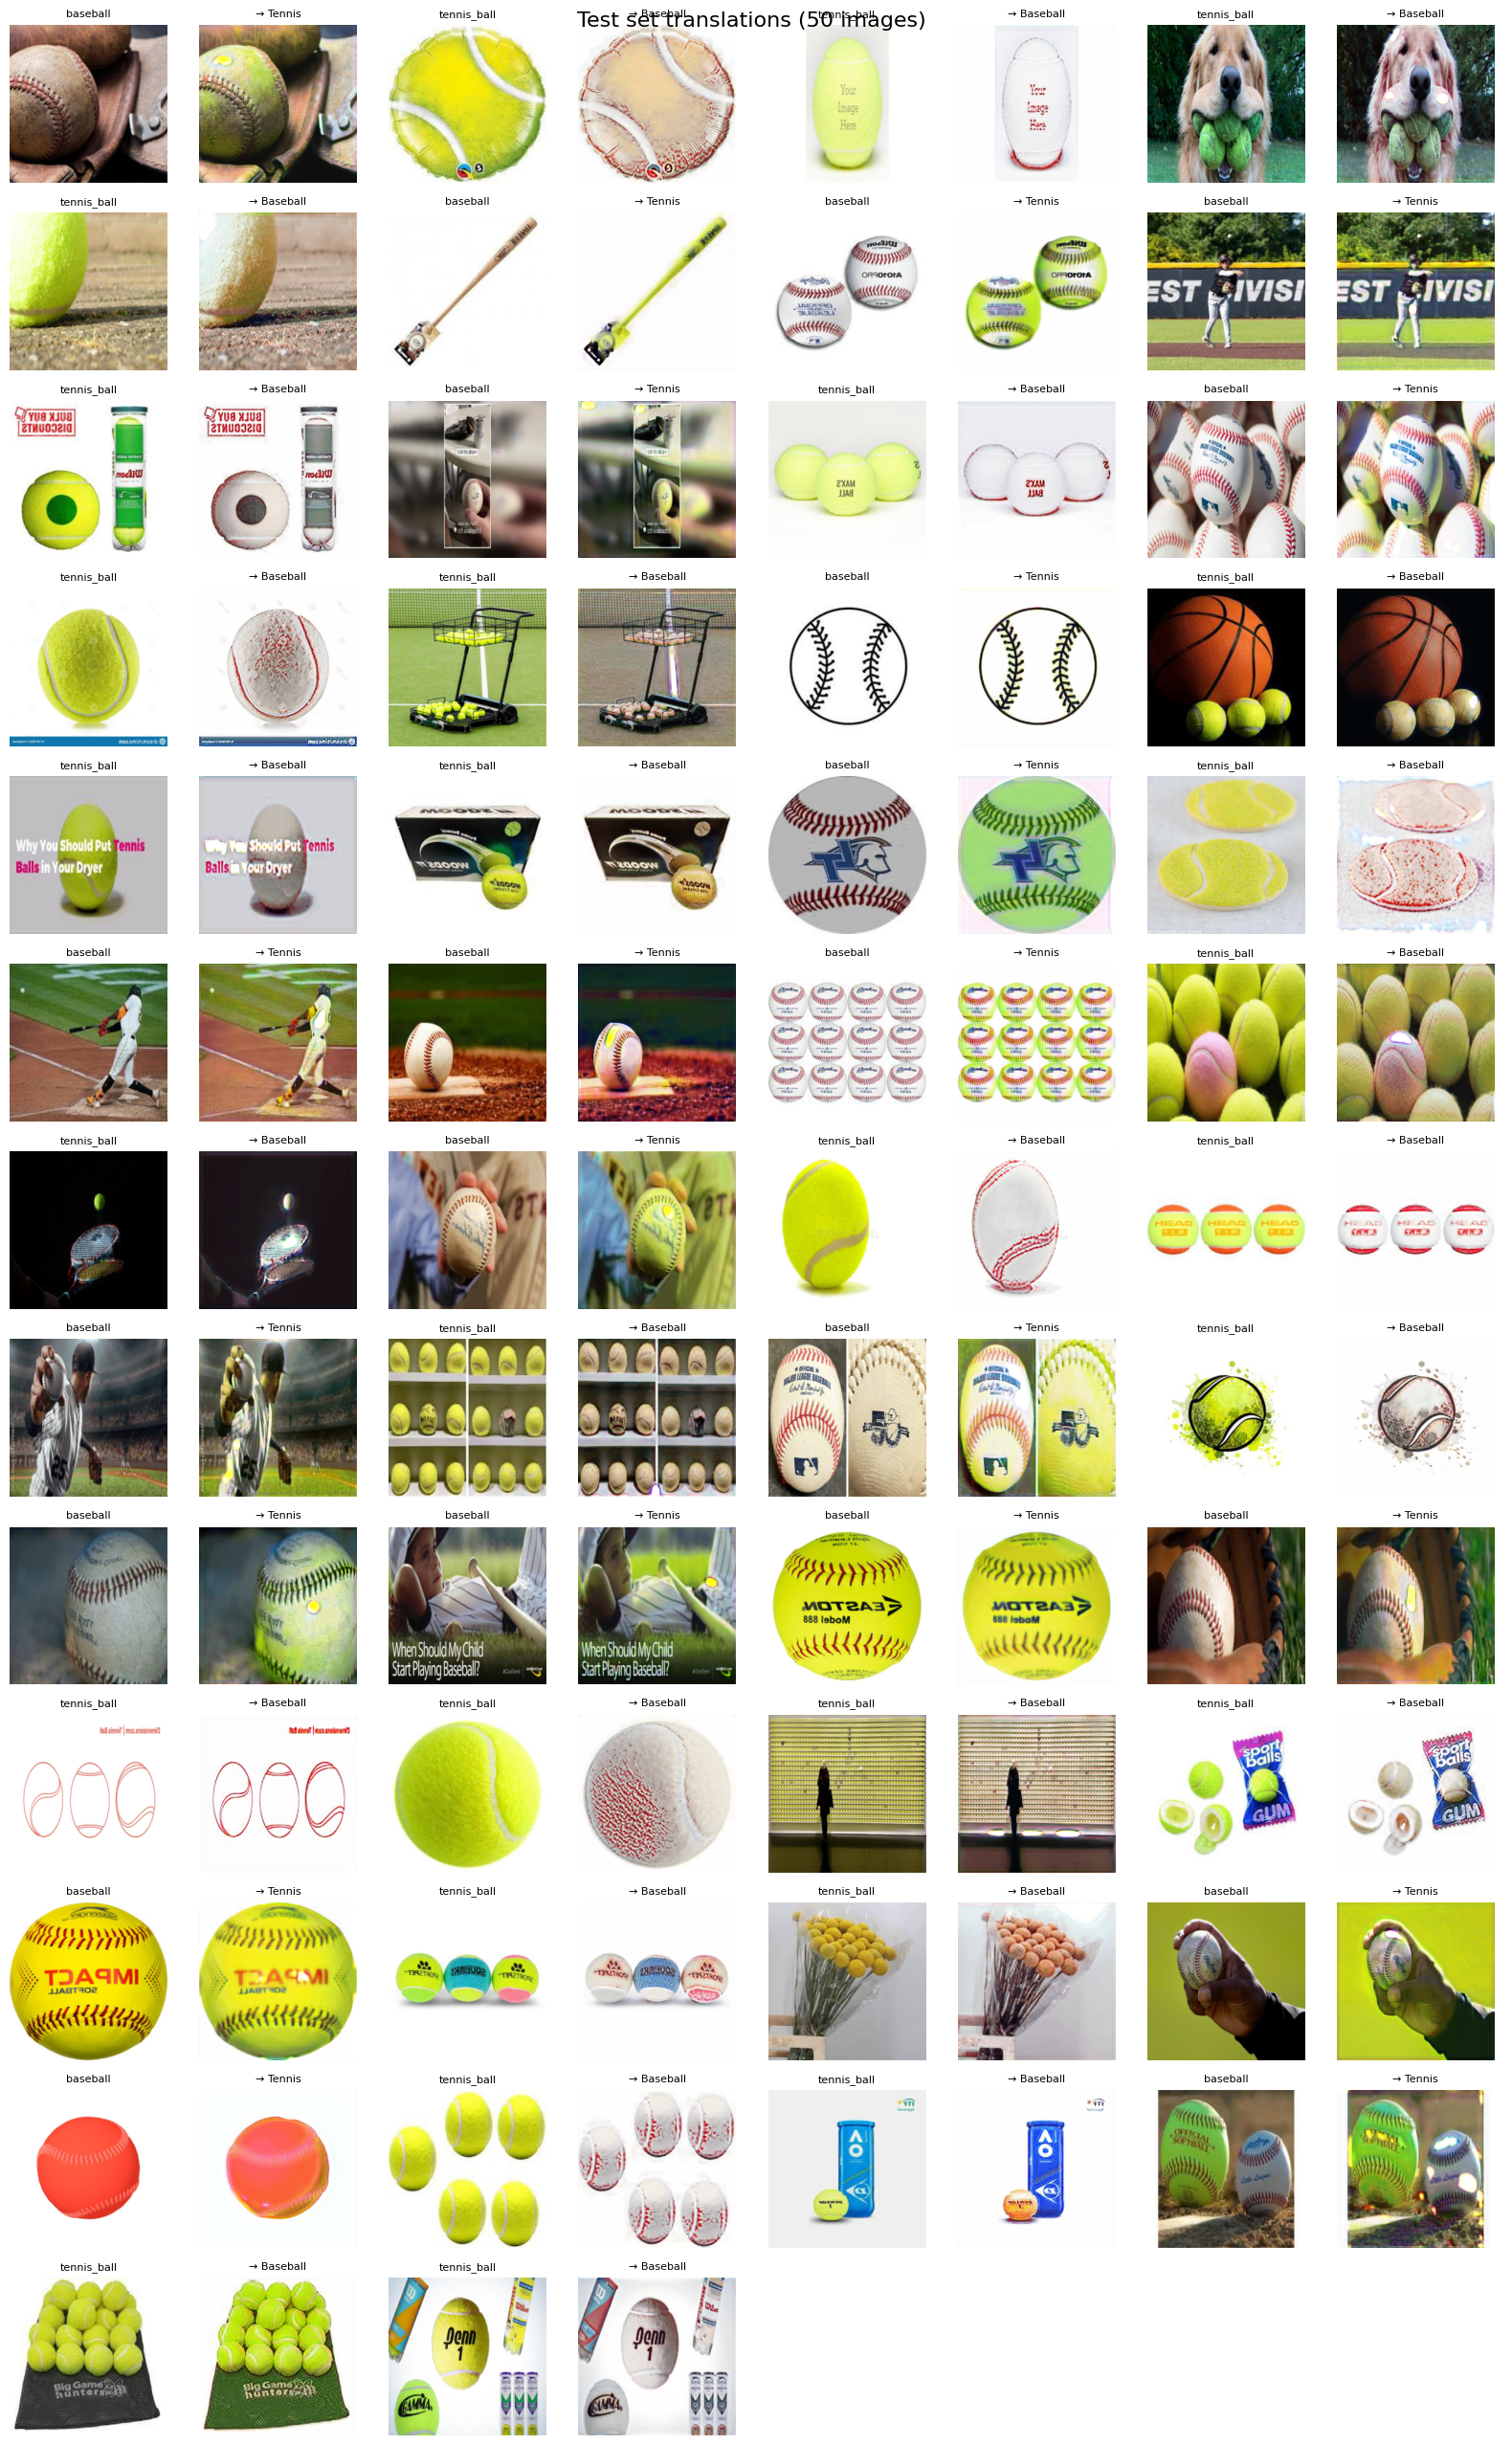

Saved grid to 'test_translations_grid.png'


In [99]:
# final inference and translations on test set
G = Generator(num_residual_blocks=6).to(device)
F = Generator(num_residual_blocks=6).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
G.load_state_dict(checkpoint['G_state_dict'])
F.load_state_dict(checkpoint['F_state_dict'])

G.eval()
F.eval()

num_test_images = 50
test_indices = random.sample(range(len(test_set)), min(num_test_images, len(test_set)))

n_pairs = len(test_indices)
n_cols = 4
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 4, n_rows * 2))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(test_indices):
        img, label = test_set[idx]
        img = img.unsqueeze(0).to(device)

        def denorm(tensor):
            return ((tensor.cpu().permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

        col_idx = i * 2

        axes[col_idx].imshow(denorm(img[0]))
        axes[col_idx].set_title(f'{output_mapping(label)}', fontsize=8)
        axes[col_idx].axis('off')

        if label == 0:
            translated = G(img)
            axes[col_idx + 1].imshow(denorm(translated[0]))
            axes[col_idx + 1].set_title('→ Tennis', fontsize=8)
        else:
            translated = F(img)
            axes[col_idx + 1].imshow(denorm(translated[0]))
            axes[col_idx + 1].set_title('→ Baseball', fontsize=8)

        axes[col_idx + 1].axis('off')

for j in range(len(test_indices) * 2, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Test set translations ({len(test_indices)} images)', fontsize=16)
plt.tight_layout()
plt.savefig('test_translations_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved grid to 'test_translations_grid.png'")